# 第8章  正则表达式


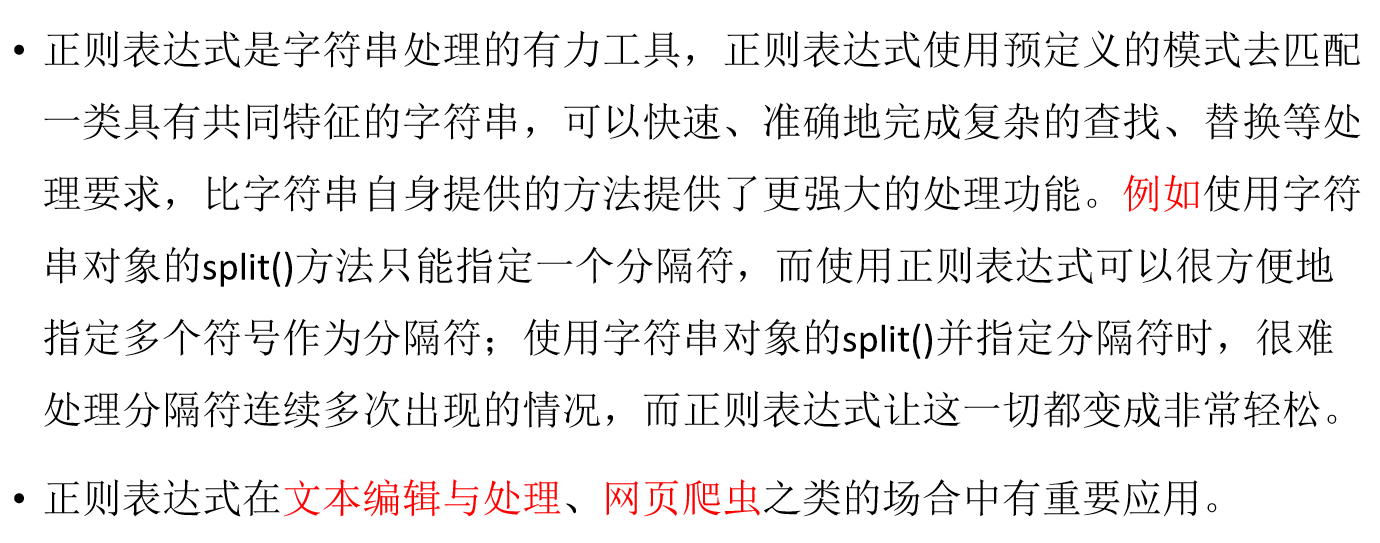

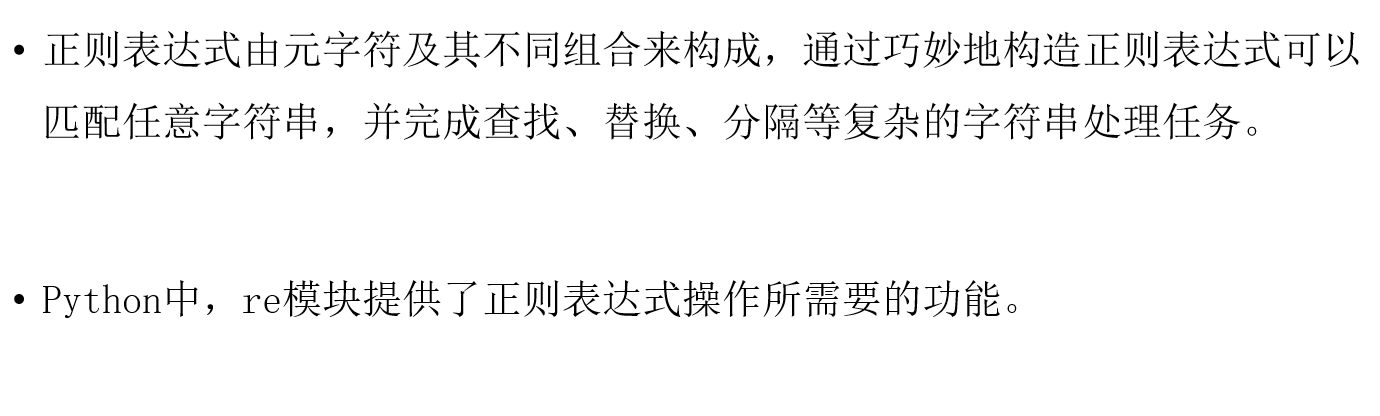

https://www.byhy.net/py/lang/extra/regex/

In [ ]:
[\d.]+万/每{0,1}月

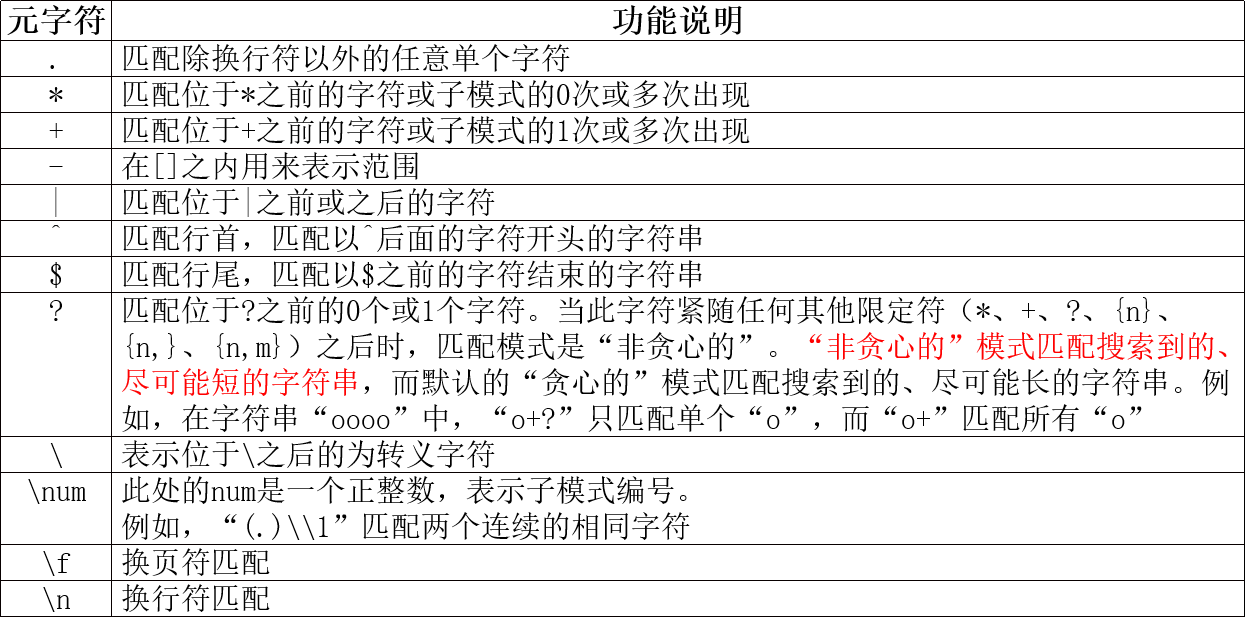

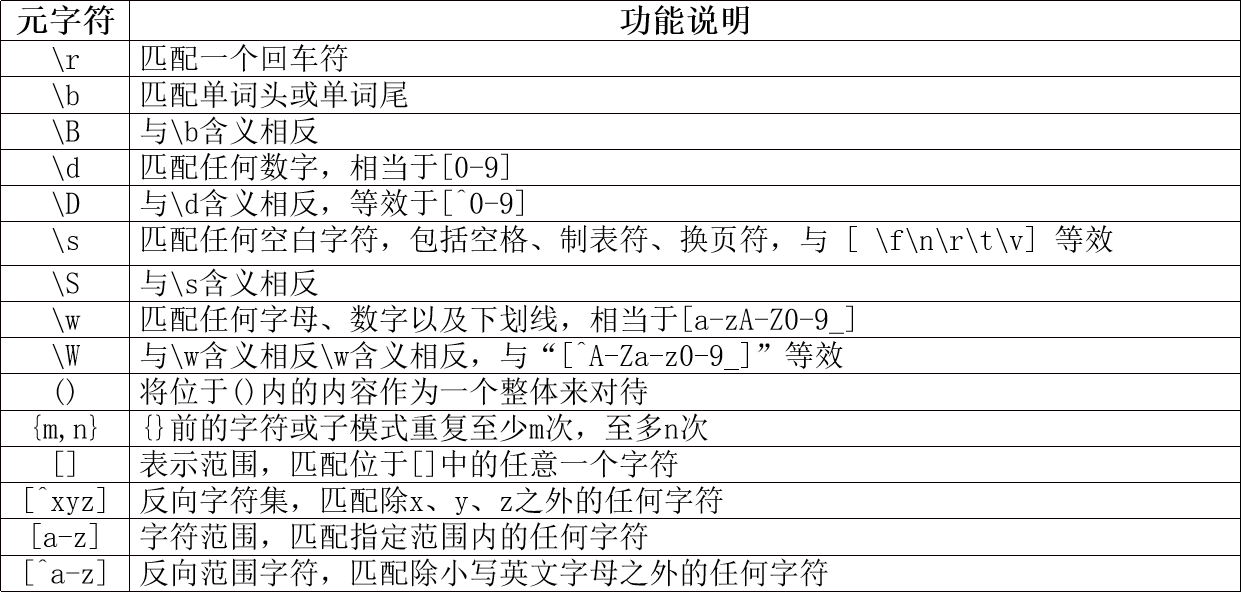

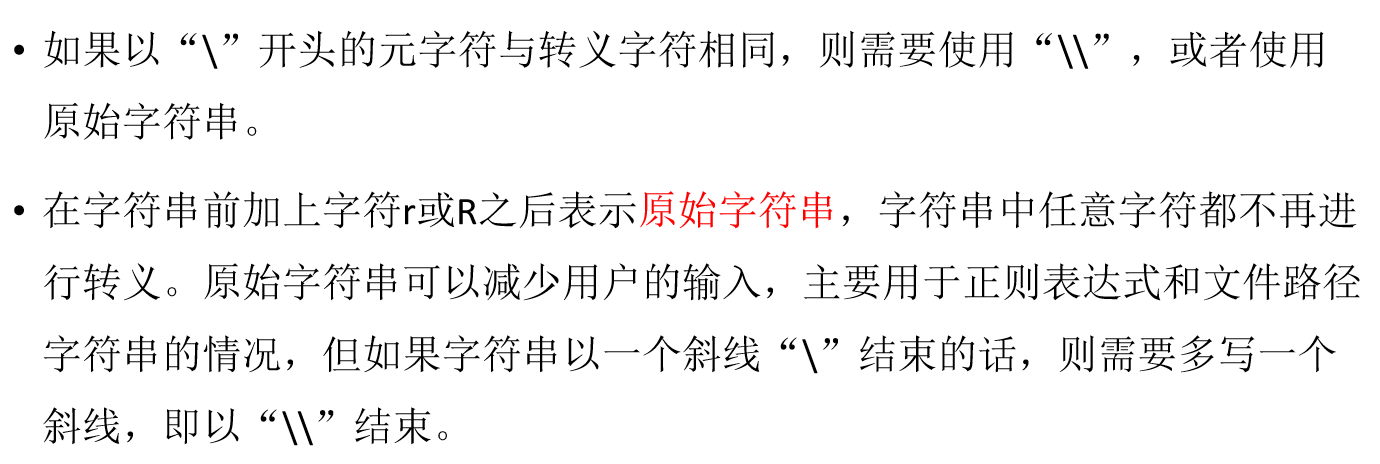

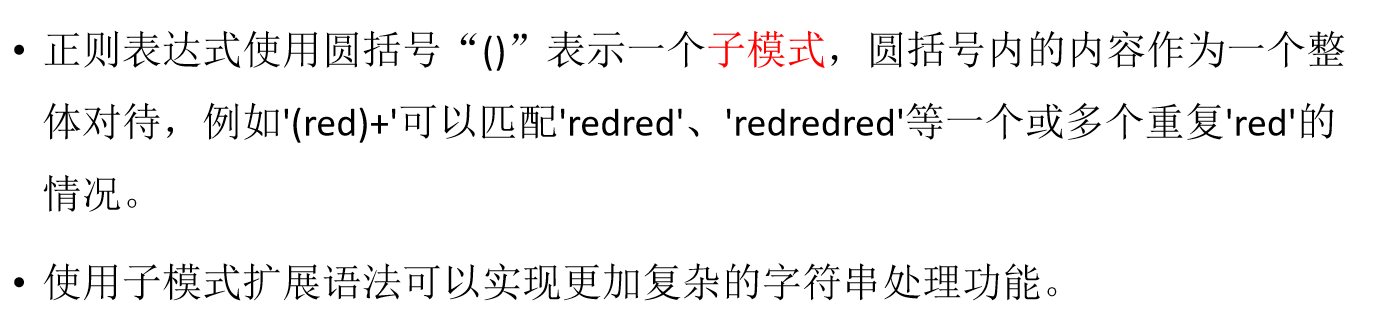

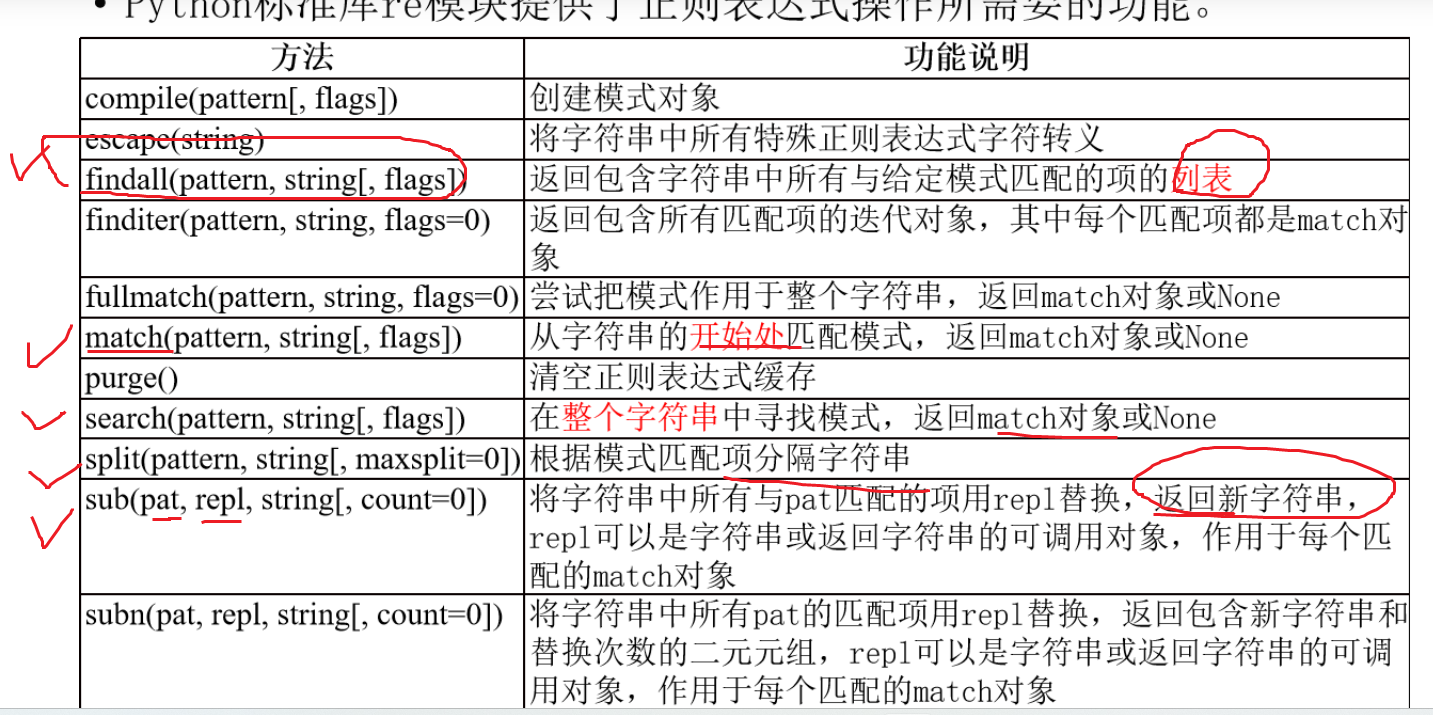

## 结合re模块来学习正则表达式

In [283]:
s = "5apple,,,peach,banana,pear55"
s.split(",")

['5apple', '', '', 'peach', 'banana', 'pear55']

In [277]:
import re
re.split(r'[,\d]+',s)

['apple', 'peach', 'banana', 'pear', '']

In [278]:
s1 = re.sub(r'[,\d]+',' ',s)
s1.strip()

'apple peach banana pear'

In [279]:
s = '\n\nhello\t\t world \n\n\n My name is Dong   '
re.split('\s+',s,1)

['', 'hello\t\t world \n\n\n My name is Dong   ']

In [280]:
s = '\n\nhello\t\t world \n\n\n My name is Dong   '
s.split(None, 1)

['hello', 'world \n\n\n My name is Dong   ']

In [284]:
s = "中国，中国"
s2 = s.replace("中国", "中华人民共和国")  #两个参数都作为一个整理
print(s2)

中华人民共和国，中华人民共和国


In [285]:
import re
re.sub('中|国','人民',s)

'人民人民，人民人民'

In [238]:
import re
re.sub('[中国]','人民',s)

'人民人民，人民人民'

In [287]:
import re
example = 'oooo ops'
re.findall('o+', example)

['oooo', 'o']

In [290]:
import re
example = 'oooo ops'
re.findall('o{2,}', example)

['oooo']

## '[pjc]ython'可以匹配'python'、'jython'、'cython'



In [41]:
import re
example = 'python jython not n but I like it.'
re.findall('[pjc]ython', example)

['python', 'jython']

In [42]:
example = 'python ijython not n but I like it.'
re.split('[pjc]ython', example) 

['', ' i', ' not n but I like it.']

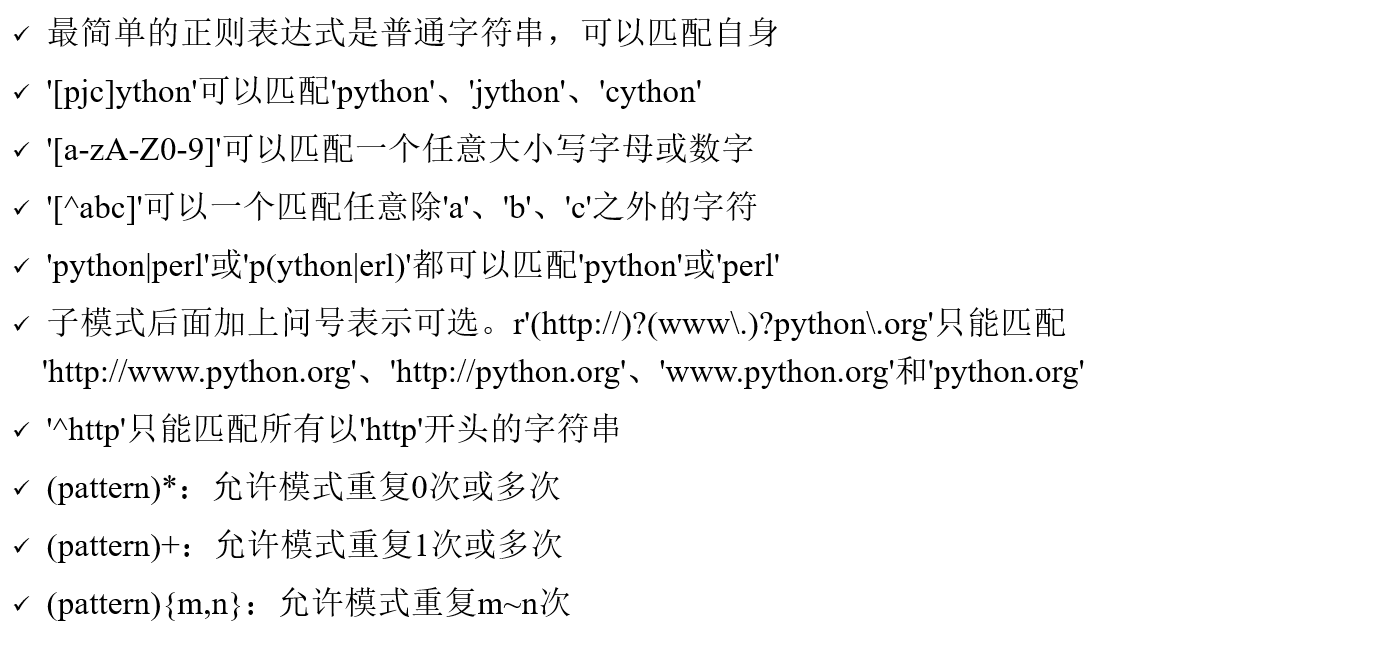

In [55]:
import re
example = 'python is not jython but I like it.'
#re.findall('[a-zA-Z0-9]', example)
#re.findall('\w', example)

In [291]:
import re
example = 'apple'
re.findall('[^p]', example)

['a', 'l', 'e']

In [295]:
import re
example = 'http.www.jiangnan.edu.cn'
re.findall(r'^http.+', example)

['http.www.jiangnan.edu.cn']

In [251]:
import re
example = 'appapple cddcddple'
re.findall('(app|cdd)+', example)

['app', 'cdd']

In [299]:
import re
example = 'appapple cddcddple'
re.findall('(app){1,}', example)

['app']

In [301]:
import re
example = 'appapple cddcddple'
re.sub('(app)+', '开心', example)

'开心le cddcddple'

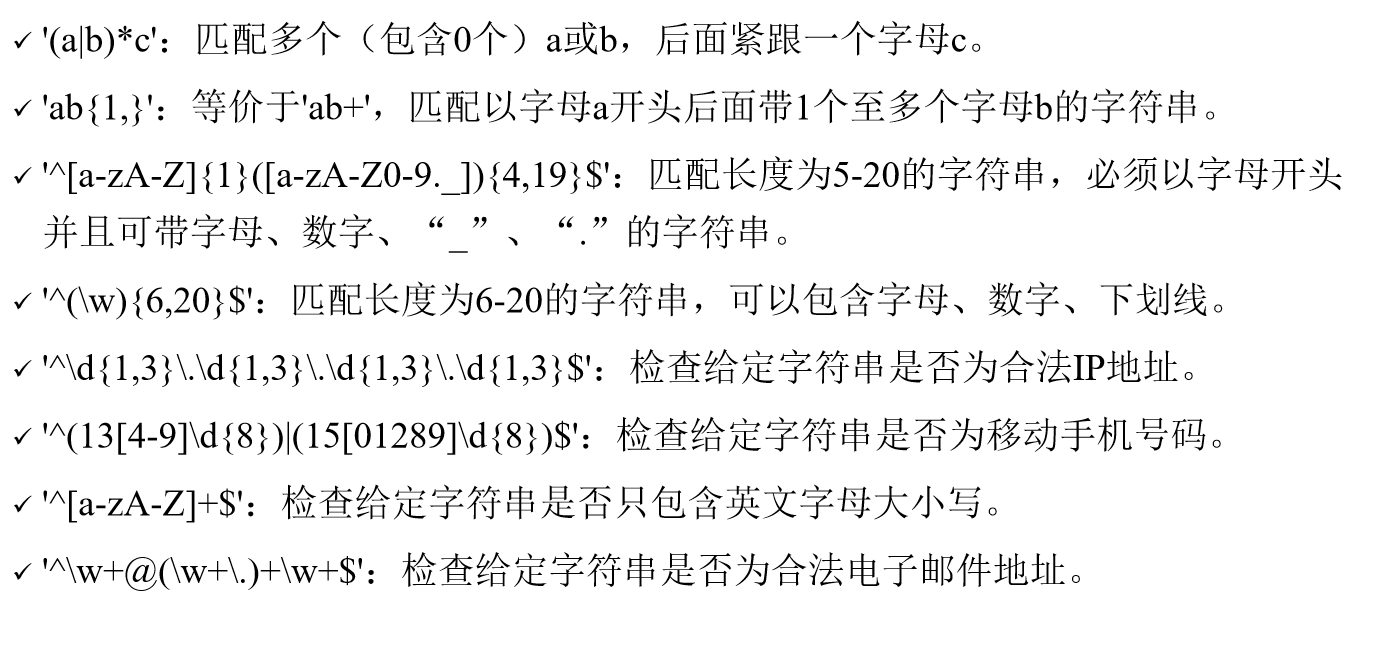

In [23]:
example = '210.12.26.24'
re.findall('^\d{1,3}.\d{1,3}.\d{1,3}.\d{1,3}$', example)

['210.12.26.24']

In [303]:
import re
example = 'myw@jiangnan.edu.cn'
re.search('^\w+@(\w+\.)+\w+$', example)

<re.Match object; span=(0, 19), match='myw@jiangnan.edu.cn'>

In [304]:
import re
example = 'myw@jiangnan.edu.cn'
re.search('^\w+@[\w\.]+$', example)

<re.Match object; span=(0, 19), match='myw@jiangnan.edu.cn'>

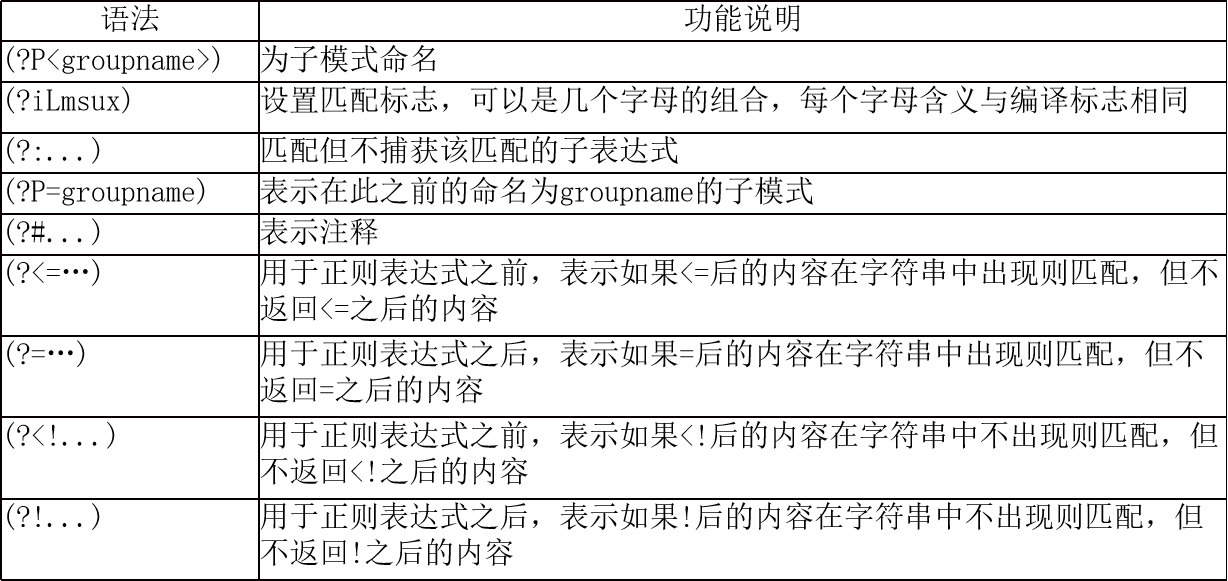

In [309]:
import re
m = re.match(r'(?P<first_name>\w+) (?P<last_name>\w+)', 'Malcolm Reynolds')
m,    m.group('first_name'), m.group('last_name')

(<re.Match object; span=(0, 16), match='Malcolm Reynolds'>,
 'Malcolm',
 'Reynolds')

In [267]:
import re
m = re.findall(r'(?P<first_name>\w+) (?P<last_name>\w+)', 'Malcolm Reynolds')
m    

[('Malcolm', 'Reynolds')]

In [311]:
import re
m = re.findall('(?P<f>.)(?P=f)(?P<g>.)(?P=g)', '高高兴兴 快快乐乐 AB AABB')
m

[('高', '兴'), ('快', '乐'), ('A', 'B')]

## (?<=...)

> ## 用于正则表达式之前，表示如果<=后的内容在字符串中出现则匹配，但不返回<=之后的内容



In [125]:
example = 'I never play basketball.'
re.findall('(?<=\w\s)never(?=\s\w)', example)

['never']

In [262]:
example = 'I never play basketballInever play'
re.sub('(?<=\w\s)never(?=\s\w)', '设计', example)

'I 设计 play basketballInever play'

## 例如，“(?<=95|98|NT|2000)Windows”能匹配“2000Windows”中的“Windows”，但不能匹配“3.1Windows”中的“Windows”

In [305]:
example = 'aWindows95 Windows3.1'
re.findall('(?<=[a-z])Windows(?=95|98|NT|2000)', example)

['Windows']

## (?=...)
> ## 用于正则表达式之后，表示如果=后的内容在字符串中出现则匹配，但不返回=之后的内容


## 例如，“Windows(?=95|98|NT|2000)”能匹配“Windows2000”中的“Windows”，但不能匹配“Windows3.1”中的“Windows”

## (?<！=...)
> ## 用于正则表达式之前，表示如果<!后的内容在字符串中不出现则匹配，但不返回<!之后的内容


## 例如“(?<![95|98|NT|2000])Windows”能匹配“3.1Windows”中的“Windows”，但不能匹配“95Windows”中的“Windows”。

In [306]:
example = '95Windows 3.1Windows'
re.findall('(?<![95|98|NT|2000])Windows', example)

['Windows']

## (?！...)

In [128]:
import re
m = re.findall(r'Windows(?!95|98|NT|2000)', 'Windows3.1 Windows2000')
m

['Windows']

In [307]:
import re
m = re.sub(r'Windows(?!95|98|NT|2000)', 'Linux', 'Windows3.1 Windows2000')
m

'Linux3.1 Windows2000'

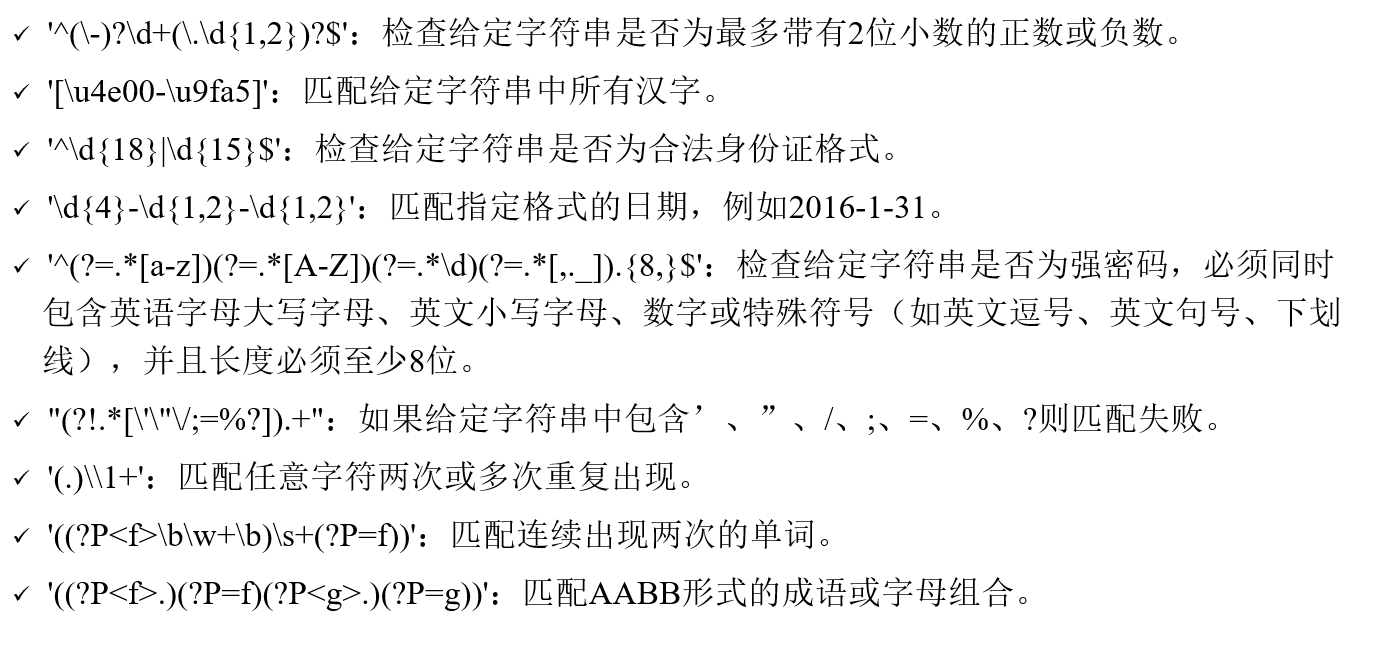

In [313]:
example = '-2.14'
re.findall('^(\-)?\d+(\.\d{1,2})?$', example)

[('-', '.14')]

In [159]:
example = 'my123_XC'
re.findall('^(?=.*[a-z])(?=.*[A-Z])(?=.*\d)(?=.*[,._]).{8,}$', example)

['my123_XC']

In [155]:
example = '2.35 5.7 2 .'
re.findall('[\d|\.]+', example)

['2.35', '5.7', '2', '.']

In [170]:
example = '%a123\' 123 '
re.findall('(?!.*[\'\"\/;=%?]).+', example)

[' 123 ']

In [168]:
example = '%a123\' 123'
re.sub('(?!.*[\'\"\/;=%?]).+','AAA', example)

"%a123'AAA"

In [314]:
import re
example = 'appapple cddcddple 高高兴兴'
re.findall('(.)\\1(.)\\2', example)

[('高', '兴')]

In [315]:
import re
m = re.findall('((.)\\2(.)\\3)', '高高兴兴 快快乐乐 AB AABB')
m

[('高高兴兴', '高', '兴'), ('快快乐乐', '快', '乐'), ('AABB', 'A', 'B')]

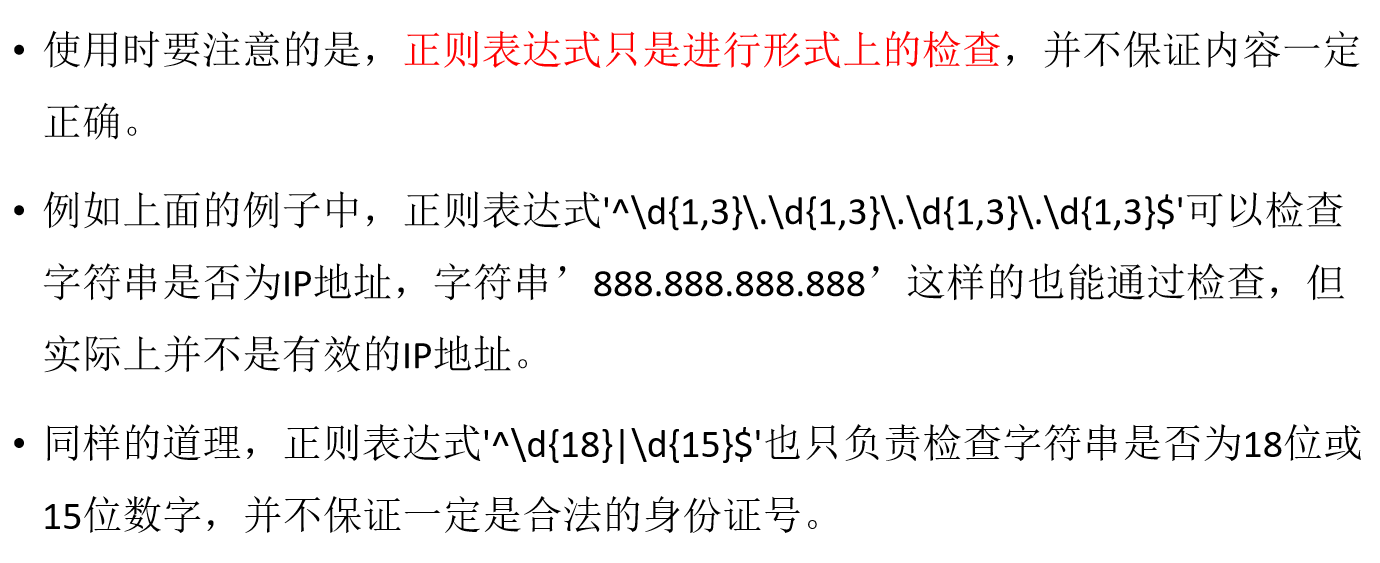

## 8.2  直接使用正则表达式模块re处理字符串


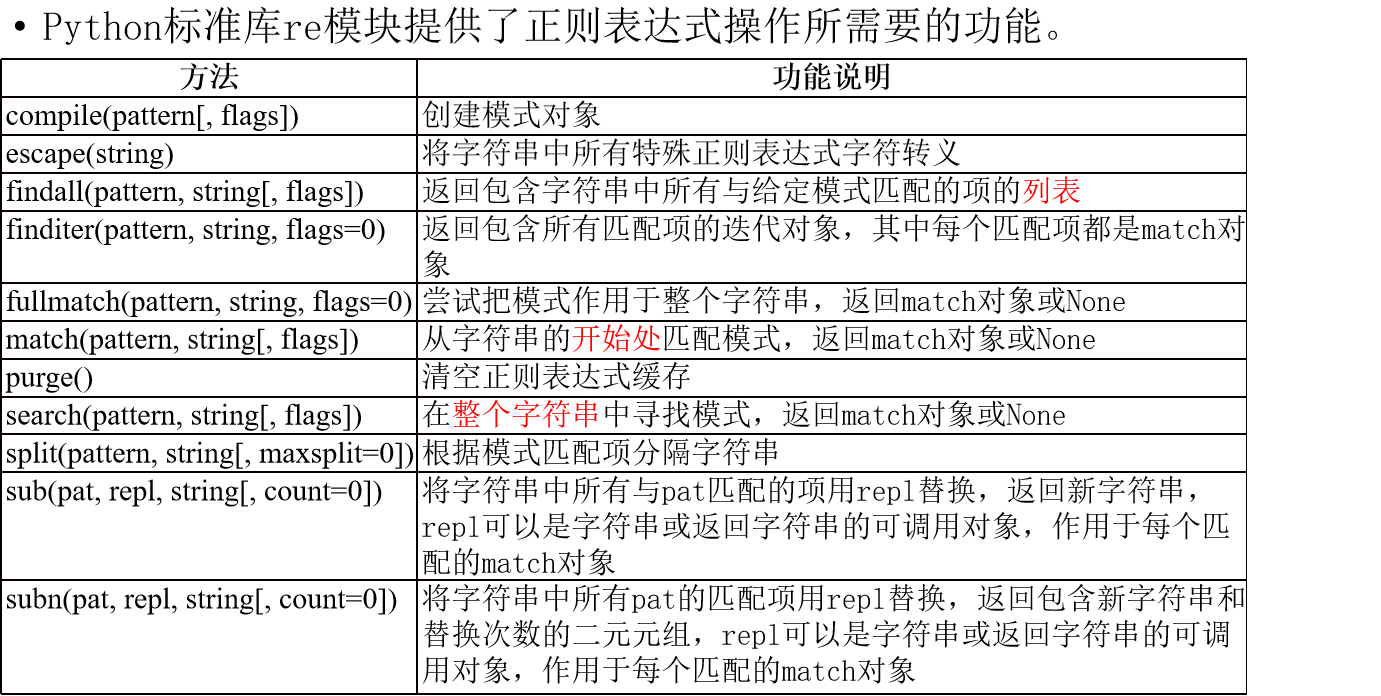

In [191]:
import re
re.escape('dw123.')

'dw123\\.'

In [192]:
print(_)

dw123\.


In [316]:
import re
print(re.match(r'The', 'The world is ...'))#从头开始匹配，开始处没有就返回None
print(re.match(r'world', 'The world is ...'))

<re.Match object; span=(0, 3), match='The'>
None


In [317]:
#第一行代码放在match那边就能匹配成功，
#在这儿却返回None，足以表明了fullmatch匹配更为严苛，需要从头到尾匹配。
print(re.fullmatch(r'The', 'The world is ...'))
# 下面的正则表达式的意思是，The后面跟着任意字符（.），且数量没有限制（*）
print(re.fullmatch(r'The.*', 'The world is ...'))

None
<re.Match object; span=(0, 16), match='The world is ...'>


In [271]:
##search和findall和上边的match和matchall的最重要差别是，
#search和findall不管头不管尾，只要在中间有地方匹配到了，
#就匹配成功了，看这方法名也可以看出匹配的严格程度较低。
print(re.search(r'_\w', 'The_world_is_...'))#返回 第一个匹配 的 Match 对象
print(re.findall(r'_\w', 'The_world_is_...'))#返回 所有匹配 的字符串列表

<re.Match object; span=(3, 5), match='_w'>
['_w', '_i']


In [272]:
import re
text = 'alpha. beta....Gamma Delta' 
pat = '[a-z]+'
s = re.finditer(pat,text)
for i in s:
    print(i.group(0))

alpha
beta
amma
elta


In [320]:
s = re.search('(.)\\1(.)\\2', '高高兴兴 快快乐乐 AB AABB')
s.group(0)

'高高兴兴'

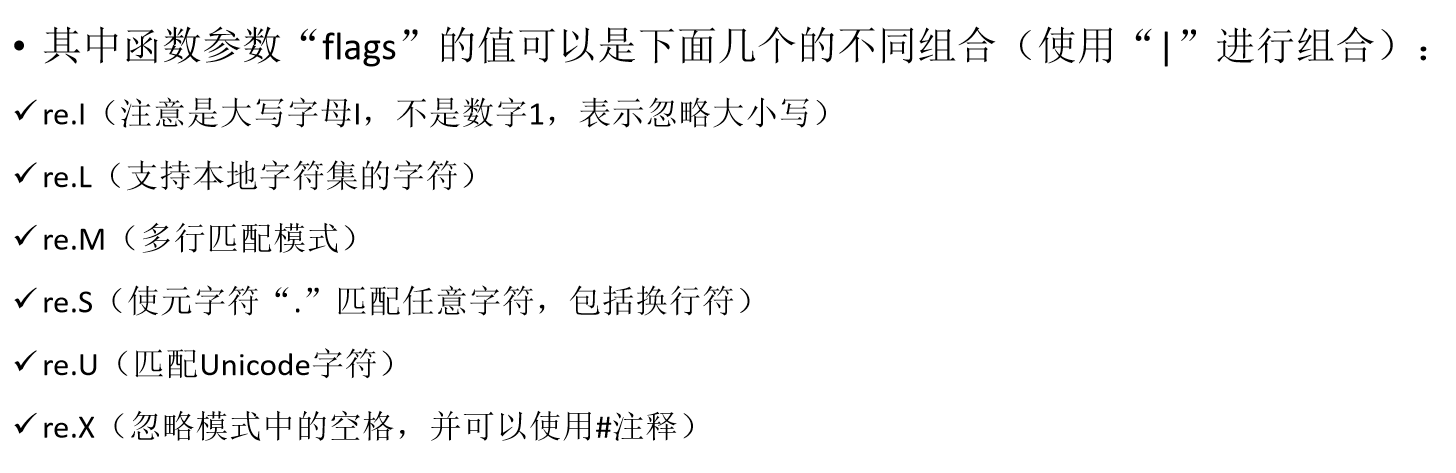

In [221]:
import re
text = 'alpha. beta....Gamma Delta' 
pat = '[a-z]+'
re.findall(pat, text, re.I)

['alpha', 'beta', 'Gamma', 'Delta']

In [222]:
import re
re.findall('(?i)[a-z]+',text)

['alpha', 'beta', 'Gamma', 'Delta']

In [8]:
import re
re.findall('[a-zA-Z]+',text)

['alpha', 'beta', 'Gamma', 'Delta']

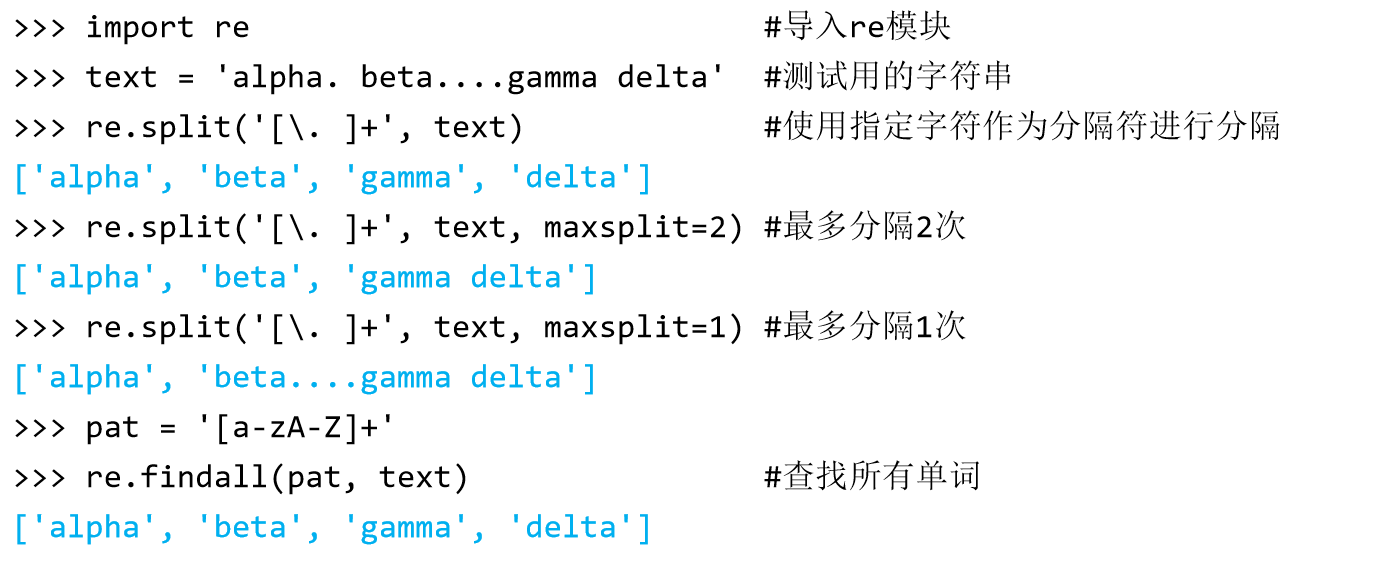

In [10]:
import re                            #导入re模块
text = 'alpha. beta....gamma delta'  #测试用的字符串
re.split('[\. ]+', text) 

['alpha', 'beta', 'gamma', 'delta']

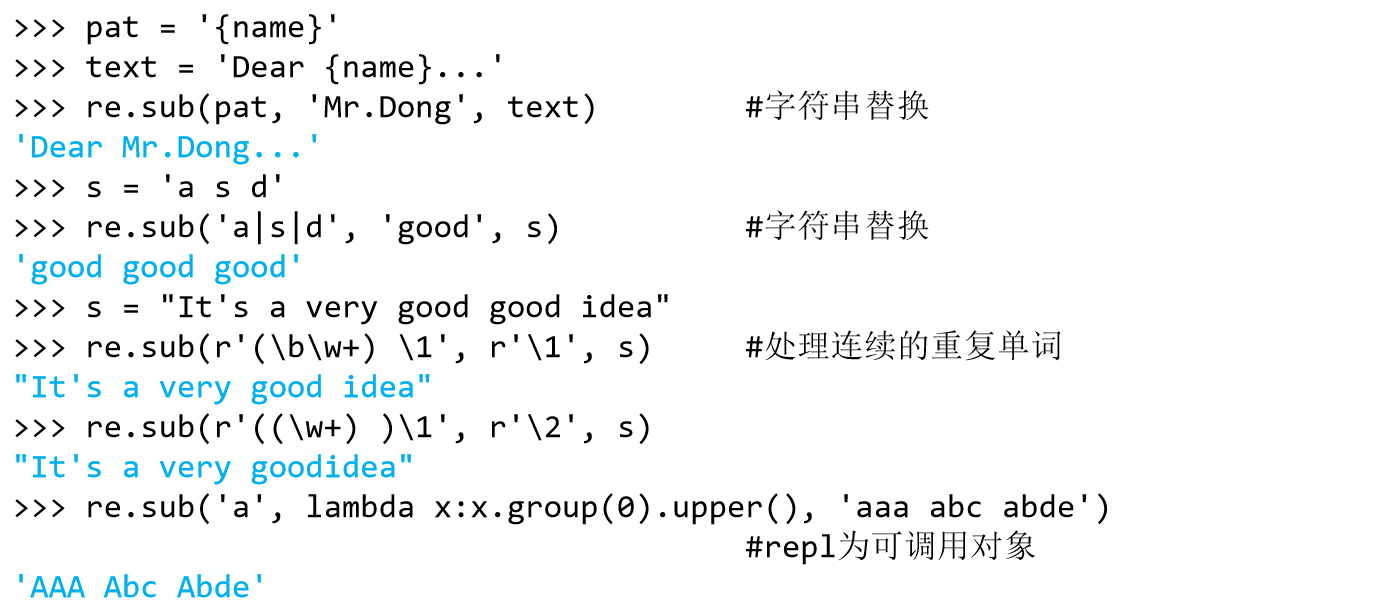

In [16]:
re.sub('[a-c]', lambda x:x.group(0).upper(), 'aaa abc abde')

'AAA ABC ABde'

In [14]:
#help(re.sub)

Help on function sub in module re:

sub(pattern, repl, string, count=0, flags=0)
    Return the string obtained by replacing the leftmost
    non-overlapping occurrences of the pattern in string by the
    replacement repl.  repl can be either a string or a callable;
    if a string, backslash escapes in it are processed.  If it is
    a callable, it's passed the Match object and must return
    a replacement string to be used.



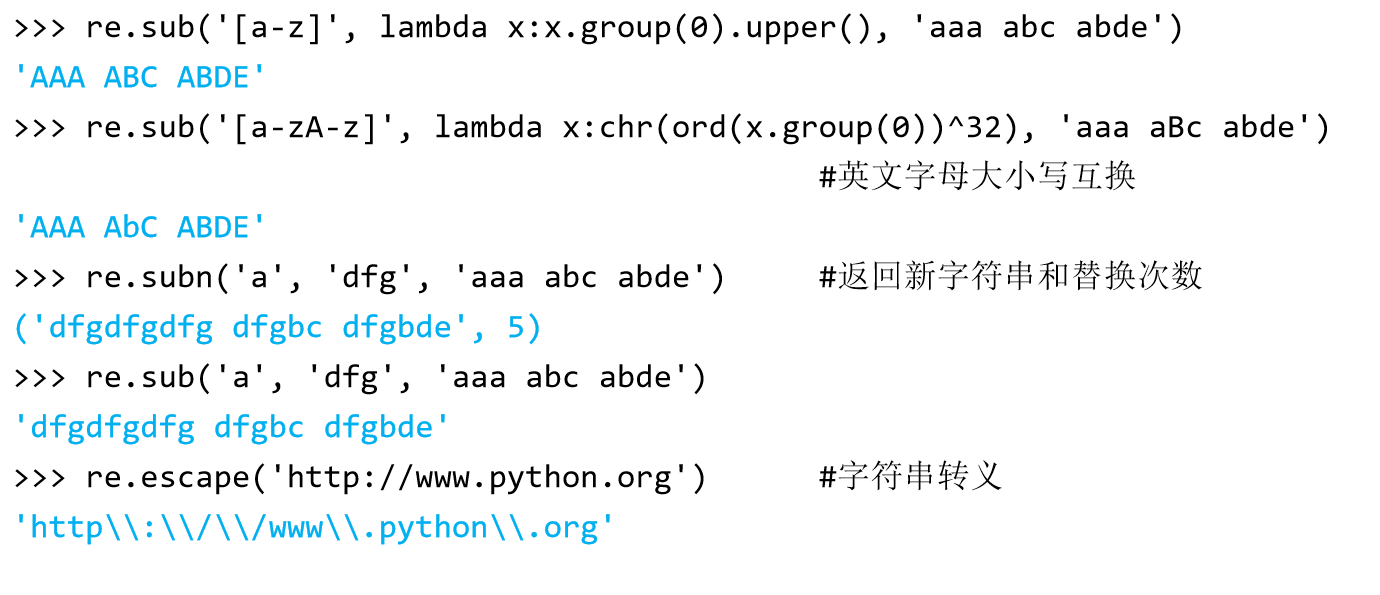

In [11]:
re.sub('[a-zA-z]', lambda x:x.group(0).swapcase(), 'aaa aBc abde')

'AAA AbC ABDE'

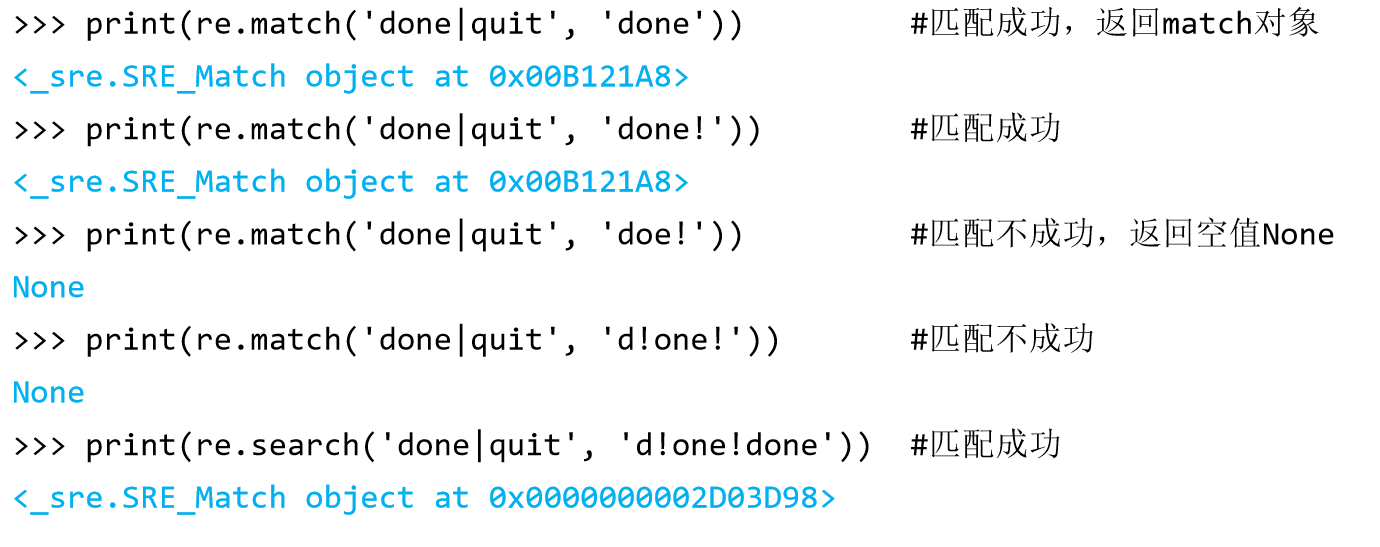

In [224]:
#print(re.match('done|quit', 'd!one!done'))

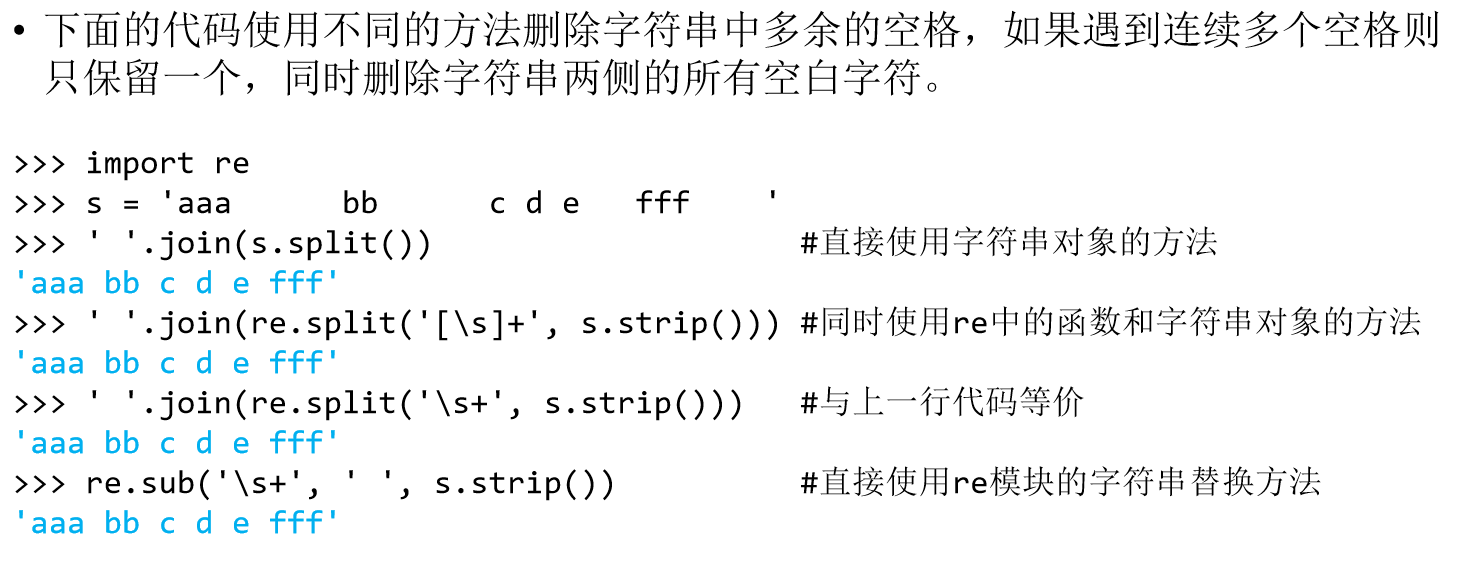

In [14]:
s = 'aaa      bb      c d e   fff    '
print(s.split())   
print(re.split('[\s]+', s.strip()))
' '.join(re.split('[\s]+', s.strip()))

['aaa', 'bb', 'c', 'd', 'e', 'fff']
['aaa', 'bb', 'c', 'd', 'e', 'fff', '']


'aaa bb c d e fff'

In [269]:
re.split('[\s]+', s.strip())

['aaa', 'bb', 'c', 'd', 'e', 'fff']

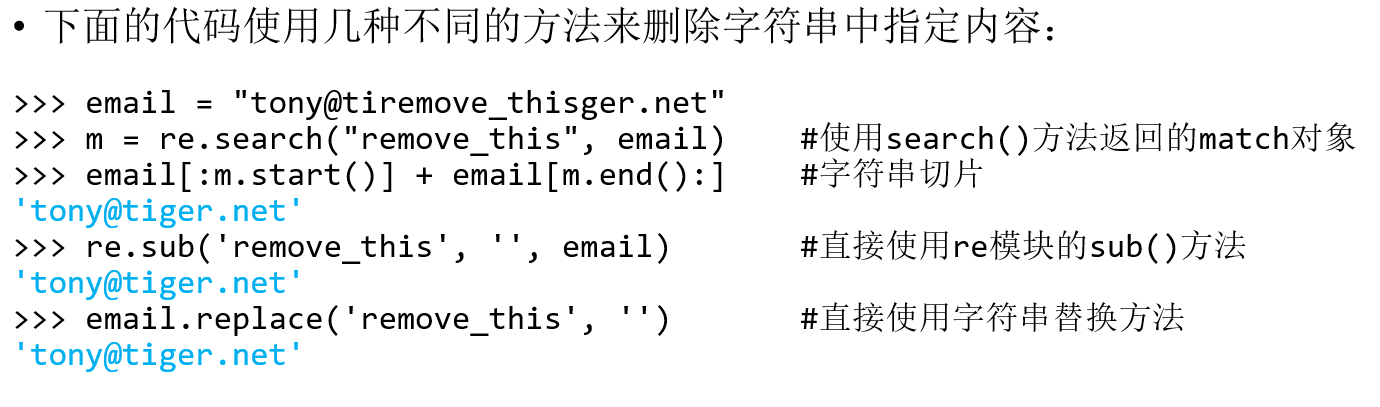

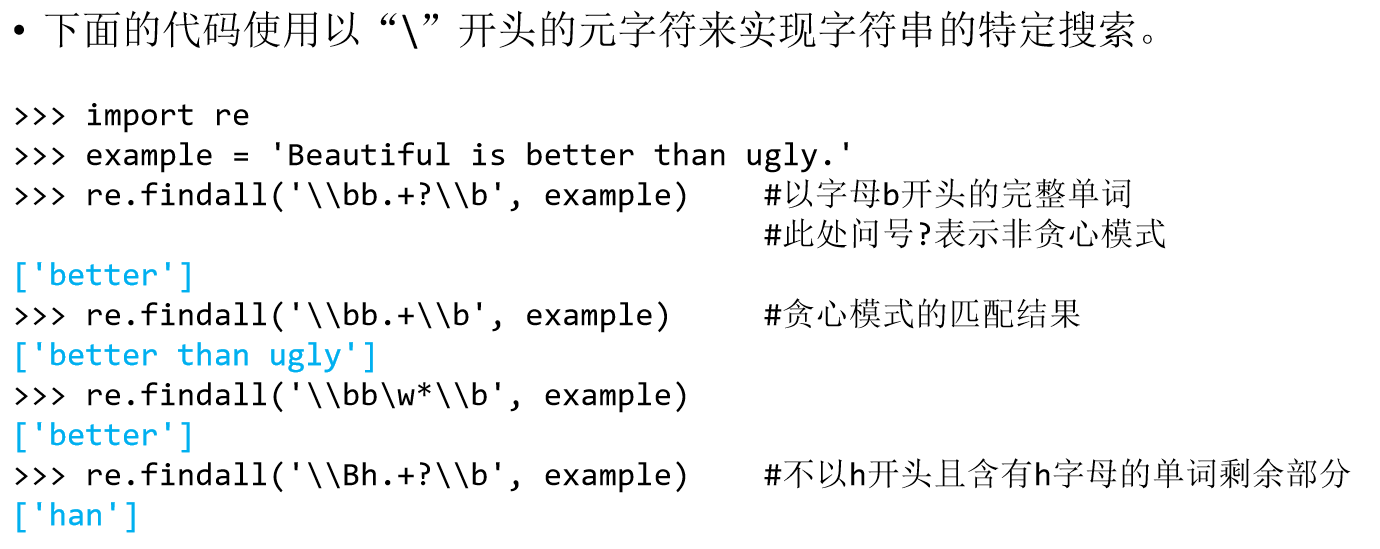

In [272]:
example = 'Beautiful is better than ugly.'
re.findall(r'\bb.+?\b', example)           #所有单词

['better']

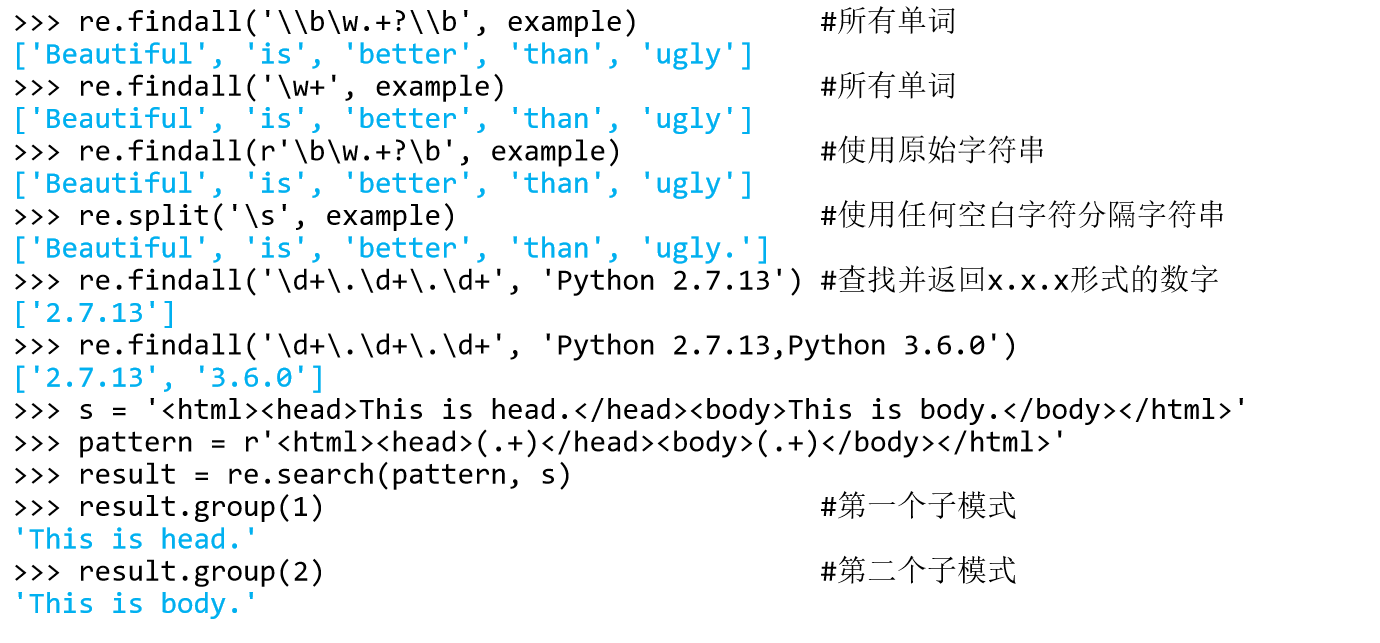

## 8.3  使用正则表达式对象处理字符串


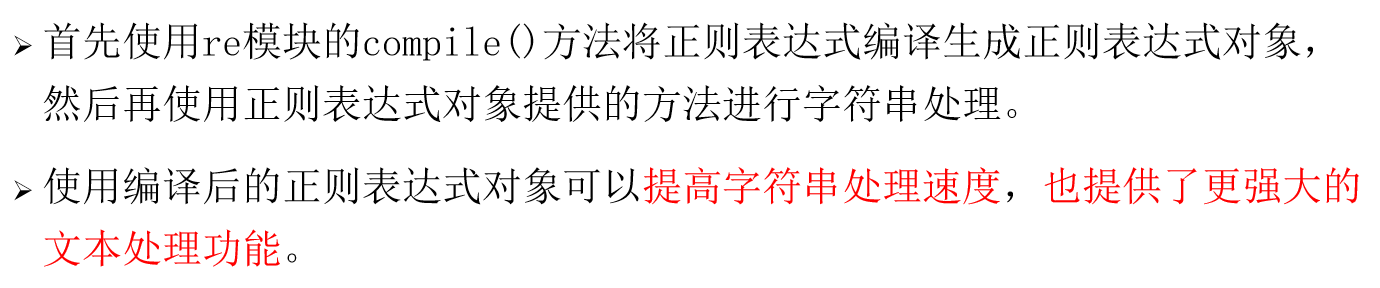

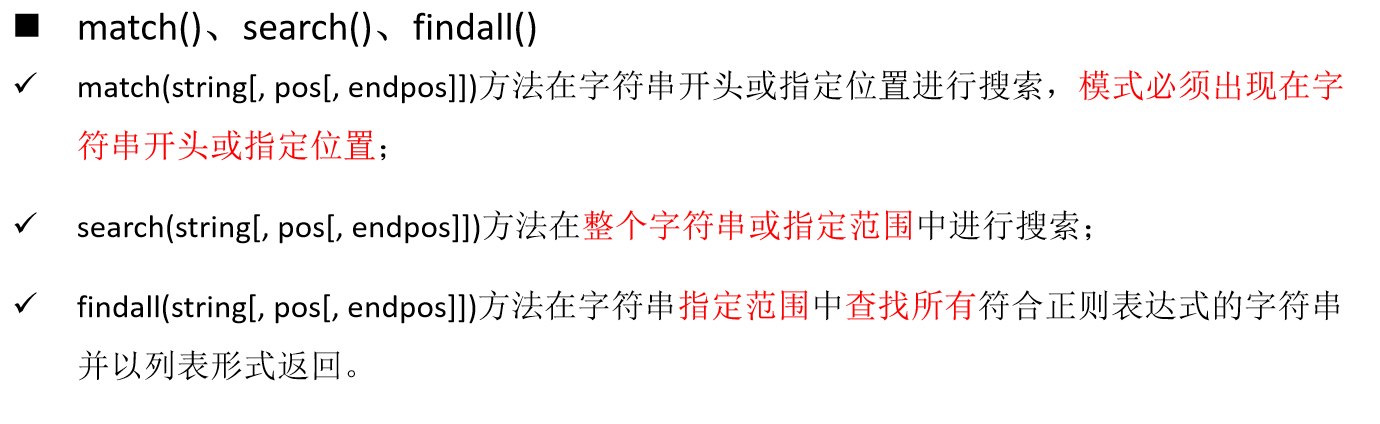

In [26]:
import re
example = 'ShanDong Institute of Business and Technology'
pattern = re.compile(r'\bB\w+\b')    #查找以B开头的单词
pattern.findall(example) 

['Business']

In [27]:
#pattern = re.compile(r'\bSh\w+\b') 
pattern.match(example)  

In [29]:
pattern.search(example)  

<re.Match object; span=(22, 30), match='Business'>

In [30]:
pattern = re.compile(r'\w+g\b')      #查找以字母g结尾的单词
pattern.findall(example)

['ShanDong']

In [24]:
pattern = re.compile(r'\b\w*a\w*\b') #查找所有含有字母a的单词
pattern.search(example)#注意，如果string中存在多个pattern子串，只返回第一个

<re.Match object; span=(0, 9), match='Beautiful'>

In [293]:
text = "He was carefully disguised but captured quickly by police."
re.findall(r"\w+ly", text) 

['carefully', 'quickly']

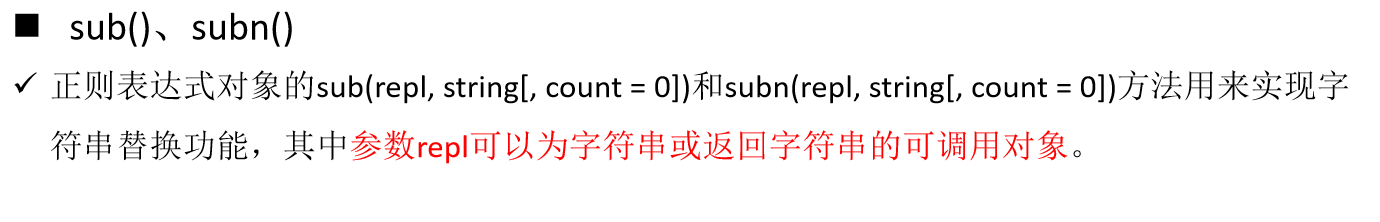

In [16]:
example = '''Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.'''

In [17]:
pattern = re.compile(r'\bb\w*\b', re.I) #匹配以b或B开头的单词
print(pattern.sub('*', example))        #将符合条件的单词替换为*

* is * than ugly.
Explicit is * than implicit.
Simple is * than complex.
Complex is * than complicated.
Flat is * than nested.
Sparse is * than dense.
Readability counts.


In [18]:
print(pattern.sub('*', example, 1))   

* is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.


In [19]:
print(pattern.sub(lambda x: x.group(0).upper(), example))

BEAUTIFUL is BETTER than ugly.
Explicit is BETTER than implicit.
Simple is BETTER than complex.
Complex is BETTER than complicated.
Flat is BETTER than nested.
Sparse is BETTER than dense.
Readability counts.


In [20]:
pattern = re.compile(r'\bb\w*\b')   #匹配以字母b开头的单词
print(pattern.sub('*', example, 1)) #将符合条件的单词替换为*
                                        #只替换1次


Beautiful is * than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.


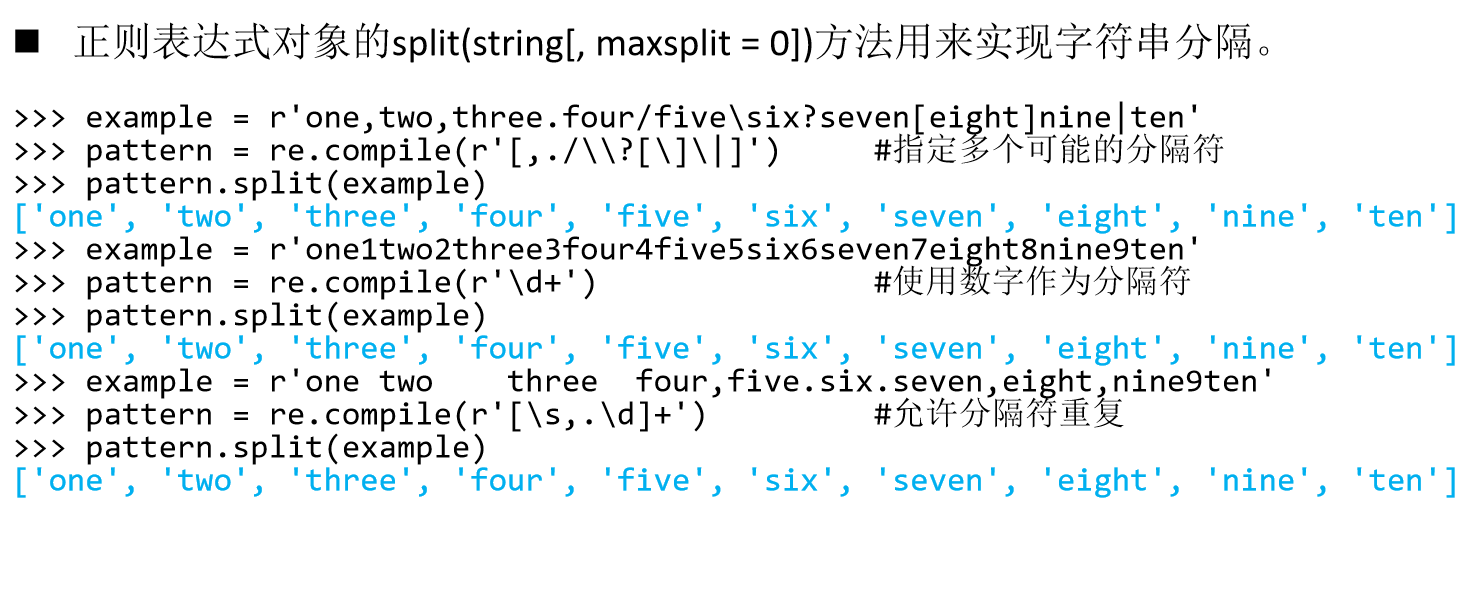

## 8.4  match对象


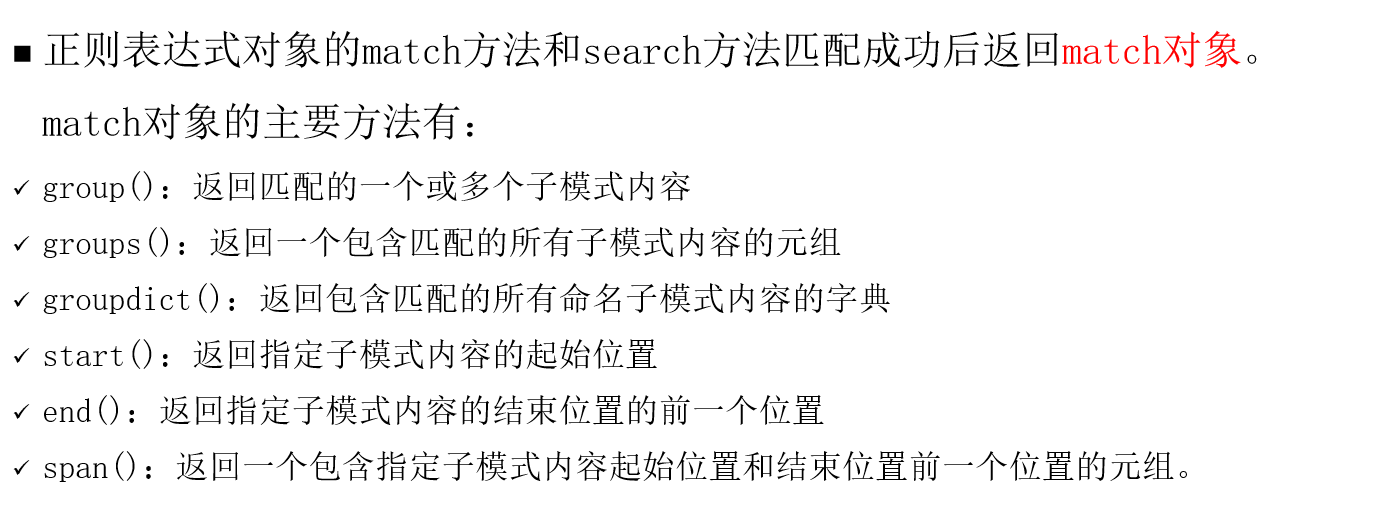

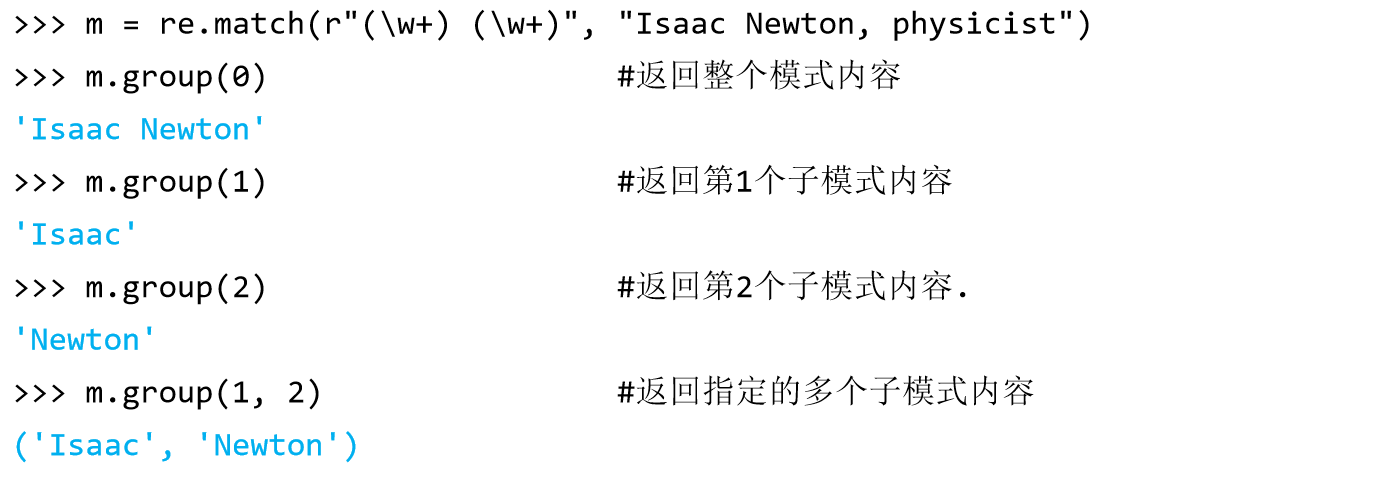

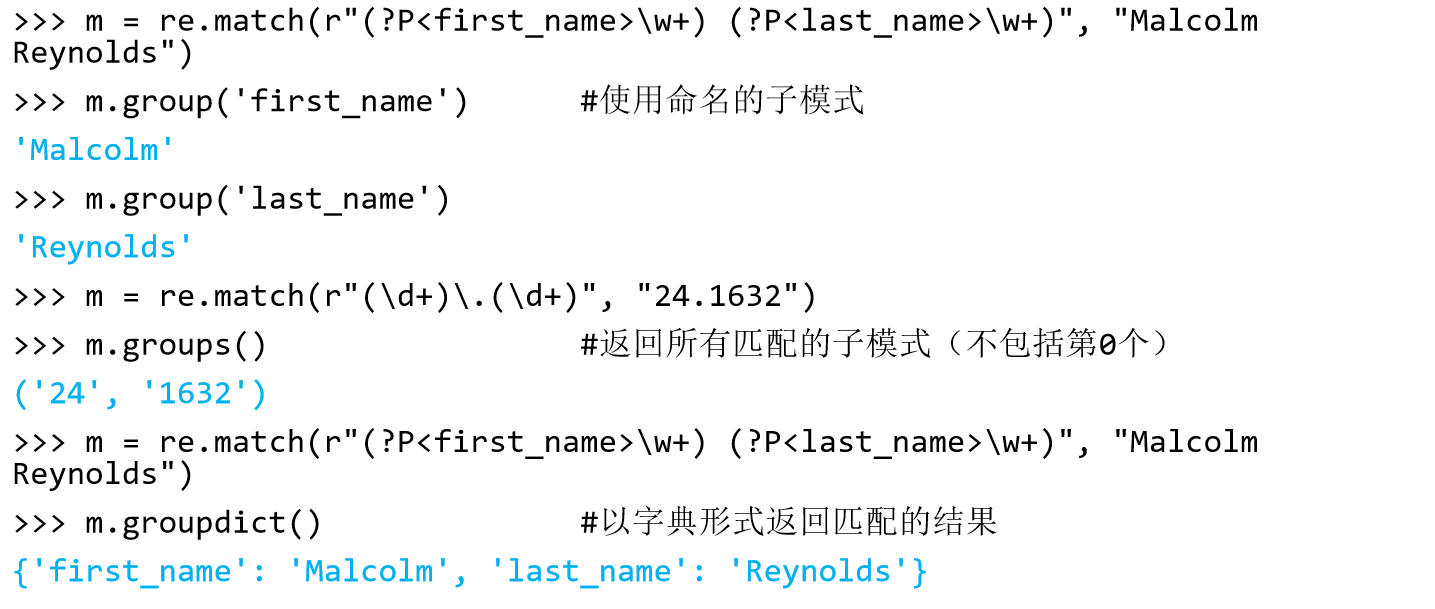

In [21]:
m = re.match(r"(\w+) (\w+)", "Isaac Newton, physicist")
m.groups()

('Isaac', 'Newton')

In [60]:
re.findall(r"(\w+) (\w+)", "Isaac Newton, physicist")

[('Isaac', 'Newton')]

In [23]:
exampleString = '''not There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than right now.'''

pattern = re.compile(r'\b(?i)n\w+\b')    #查找以n或N字母开头的所有单词
index = 0
while True:
    matchResult = pattern.search(exampleString, index)
    if not matchResult:
        break
    print(matchResult.group(0), ':', matchResult.span(0))
    index = matchResult.end(0)+1

index

not : (0, 3)
not : (96, 99)
Now : (141, 144)
never : (160, 165)
never : (176, 181)
now : (209, 212)


213

In [25]:
import re
exampleString = '''There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than right now.'''

pattern = re.compile(r'\b(?i)n\w+\b')
matchResult = pattern.search(exampleString)
matchResult1 = pattern.findall(exampleString)
matchResult,matchResult1

(<re.Match object; span=(92, 95), match='not'>,
 ['not', 'Now', 'never', 'never', 'now'])

In [39]:
pattern = re.compile(r'(?<!not\s)be\b') #查找前面没有单词not的单词be

In [51]:
pattern = re.compile(r'(\b\w*(?P<f>\w+)(?P=f)\w*\b)') 
index = 0
while True:
    matchResult = pattern.search(exampleString, index)
    if not matchResult:
        break
    print(matchResult.group(0), ':', matchResult.group(1,2))
    index = matchResult.end(0)+1
index

unless : ('unless', 's')
better : ('better', 't')
better : ('better', 't')


197

In [320]:
s = 'aabc abcd abbcd abccd abcdd'
pattern.findall(s)

[('aabc', 'a'), ('abbcd', 'b'), ('abccd', 'c'), ('abcdd', 'd')]